# Topics in Quantitative Finance - Homework 1

Assigned: July 24, 2026.
Due: **Monday, July 27, 2026** by 1PM. 

Late homework **will not be accepted**.

$$
\newcommand{\supp}{\mathrm{supp}}
\newcommand{\E}{\mathbb{E} }
\newcommand{\Eof}[1]{\mathbb{E}\left[ #1 \right]}
\def\Cov{{ \mbox{Cov} }}
\def\Var{{ \mbox{Var} }}
\newcommand{\1}{\mathbf{1} }
\newcommand{\PP}{\mathbb{P} }
\newcommand{\Pof}[1]{\mathbb{P}\left[ #1 \right]}
%\newcommand{\Pr}{\mathrm{Pr} }
\newcommand{\QQ}{\mathbb{Q} }
\newcommand{\RR}{\mathbb{R} }
\newcommand{\DD}{\mathbb{D} }
\newcommand{\HH}{\mathbb{H} }
\newcommand{\spn}{\mathrm{span} }
\newcommand{\cov}{\mathrm{cov} }
\newcommand{\sgn}{\mathrm{sgn} }
\newcommand{\HS}{\mathcal{L}_{\mathrm{HS}} }
%\newcommand{\HS}{\mathrm{HS} }
\newcommand{\trace}{\mathrm{trace} }
\newcommand{\LL}{\mathcal{L} }
%\newcommand{\LL}{\mathrm{L} }
\newcommand{\s}{\mathcal{S} }
\newcommand{\ee}{\mathcal{E} }
\newcommand{\ff}{\mathcal{F} }
\newcommand{\hh}{\mathcal{H} }
\newcommand{\bb}{\mathcal{B} }
\newcommand{\dd}{\mathcal{D} }
\newcommand{\g}{\mathcal{G} }
\newcommand{\p}{\partial}
\newcommand{\half}{\frac{1}{2} }
\newcommand{\T}{\mathcal{T} }
\newcommand{\bi}{\begin{itemize}}
\newcommand{\ei}{\end{itemize}}
\newcommand{\beq}{\begin{equation}}
\newcommand{\eeq}{\end{equation}}
\newcommand{\beas}{\begin{eqnarray*}}
\newcommand{\eeas}{\end{eqnarray*}}
\newcommand{\cO}{\mathcal{O}}
\newcommand{\cF}{\mathcal{F}}
\newcommand{\cL}{\mathcal{L}}
\newcommand{\BS}{\text{BS}}
$$

<font color = "red">Homework is to be done by each student individually.  To receive full credit, you must email a completed copy of this Jupyter notebook to TAs at [topics_in_qf@163.com](mailto:topics_in_qf@163.com) by the due date and time.  All codes must run correctly and solutions must be written up neatly in Markdown/LaTeX format. If you encounter problems with Jupyter notebook, please contact TA [李新宇](mailto:xinyu911@stu.pku.edu.cn) or [林文鑫](mailto:vincent_lin@stu.pku.edu.cn).

## Name: msj

$B_t$ deontes a standard Brownian motion in the following. 

### 1. (5 points)

Let $X_t = k B_{t/k^2}$, where $k \neq 0$ is constant. Show by definition that $X_t$ is also a standard Brownian motion. 

### <font color=blue> Solution 1. </font>
We only need to verify the followings:
1. Initial value is 0: $X_0=kB_0=0$ a.s. .
   
3. Gaussian increments: for $t,s \ge 0$,
   $$
   X_{t+s}-X_s=k(B_{\frac{t+s}{k^2}}-B_{\frac{s}{k^2}}).
   $$

   Since $B_{\frac{t+s}{k^2}}-B_{\frac{s}{k^2}}\sim N(0,\frac{t}{k^2})$,
   $$
   X_{t+s}-X_s\sim N(0,t).
   $$
4. Independent increments: For $0\le t_0<t_1<\cdots<t_m$, since $k^2\gt 0$,we still have
   $$
   0\le \frac{t_0}{k^2}<\frac{t_1}{k^2}<\cdots<\frac{t_m}{k^2}.
   $$
   The time points are increasing. Hence the increments
   $$B_{t_j/k^2}-B_{t_{j-1}/k^2},\quad j=1,\ldots,m,$$
   are independent. Multiplying by the constant $k$ preserves independence, so the increments of $X_t$ are independent.
   
5. Continuity: For almost every sample point $\omega$, the map $u\mapsto B_u(\omega)$ is continuous. Since $t\mapsto t/k^2$ is continuous, $t\mapsto X_t(\omega)=kB_{t/k^2}(\omega)$ is also continuous.

Hence we are done!

## Donsker's invariance principle

Recall the Donsker's invariance principle: 


Suppose $\{X_i\}_{i=1}^\infty$ is an iid sequence of random variables with mean 0 and and variance 1. Let $S_n = \sum_{i=1}^n X_i$. Define the function $\mathfrak{S}_n$ of $t$ by 

$$
  \mathfrak{S}_n(t) = \frac1{\sqrt n}\sum_{i=1}^n\left[S_{i-1} + n \left( t-\frac{i-1}n \right) X_i \right]\,\1_{\left(\frac{i-1}n,\frac in\right]}(t) .
$$

In fact, $\mathfrak{S}_n$ is simply the linear interpolation of the scaled random walk $\left\{\frac{S_1}{\sqrt n}, \frac{S_2}{\sqrt n}, \cdots, \frac{S_n}{\sqrt n} \right\}$.

Then, $\mathfrak{S}_n\Longrightarrow W$ as $n\to\infty$, where $W$ denotes a standard Brownian motion. 

In other words, as $n\to\infty$, the linearly interpolated scaled random walk $\mathfrak{S}_n$ converges weakly to a standard Brownian motion. 

### 2. (10pts)
In this problem, we show, numerically by simulation, the Donsker's invariance principle with the iid sequence $X_i$ being 

- (a) $X_i \sim t_3$, i.e., the $t$ distribution with degrees of freedom 3;
- (b) $X_i \sim \exp(1)$, i.e., exponential distribution with mean 1.

Consider the Brownian motion in the time interval $[0,2]$, use $100$ time steps and generate $15,000$ sample paths to reproduce the plots for sample mean, sample standard deviation, and the histograms at $t=1$ and $t=2$. To begin with, please set the random seed by including ``numpy.random.seed(9527)`` on top of your code. 

In [1]:
# as always, import required modules and functions
import numpy as np
from numpy import sqrt, log, exp
import matplotlib.pyplot as plt
import scipy.stats as ss
from scipy.stats import norm
import seaborn as sns

### <font color=blue> Solution 2(a). </font>

For t distribution, $E(T)=0$, $Var(T)=\frac 3{3-2}=3$

Donsker's Thm requires iid and variance one, so we use $X_i=T_i/\sqrt 3$

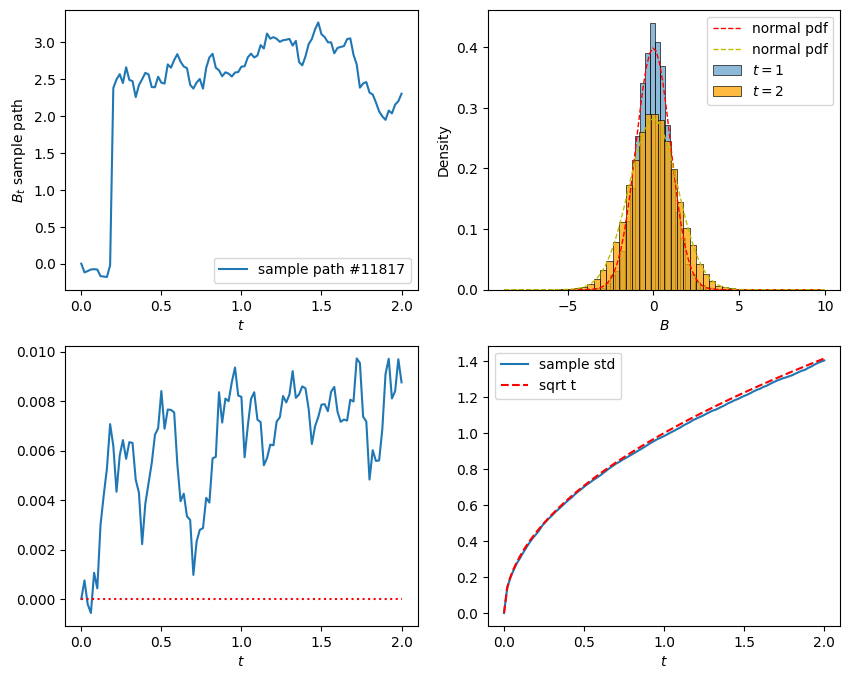

In [2]:
# insert python code for (2a) in this cell
np.random.seed(9527)

# Simulate BM by using the Donsker's invariance principle
# number of samples, number of steps, terminal time
n_sim, n_steps, T = 15000, 100, 2  
dt = T/n_steps

# initialize the Brownians
B = np.zeros([n_sim, n_steps+1])

# simulation step
for i in range(n_steps):
    dB = ss.t.rvs(df=3, size=n_sim) 
    # dB = dB - dB.mean() # now dB has mean 0
    # dB = dB/dB.std()  # now dB has variance 1 
    # t_3 mean 0 var=3/(3-2)=3
    dB =dB/sqrt(3)
    dB = np.sqrt(dt)*dB
    B[:,i+1] = B[:,i] + dB 

    
#===========
# plot
t = np.arange(0, T+dt, dt)
#t = np.linspace(0, T, n_steps+1)
plt.figure(figsize=(10, 8))

# sample path
path = np.random.choice(n_sim)
plt.subplot(2, 2, 1)
plt.plot(t, B[path, :], label=f'sample path #{path}')
plt.xlabel('$t$')
plt.ylabel('$B_t$ sample path')
plt.legend()

# histograms
plt.subplot(2, 2, 2)
time = 1
sns.histplot(B[:,t==time], bins=50, stat='density', label=f'$t={time}$')
sns.histplot(B[:,-1], bins=50, stat='density', color='orange', label=f'$t={T}$')
x = np.linspace(B[:,-1].min(), B[:,-1].max(), 100)
plt.plot(x, norm.pdf(x), 'r--', lw=1, label='normal pdf')
plt.plot(x, norm.pdf(x, scale=sqrt(2)), 'y--', lw=1, label='normal pdf') 
plt.xlabel('$B$')
plt.legend();

# sample mean
plt.subplot(2, 2, 3)
plt.plot(t, B.mean(axis=0))
plt.hlines(y=0, xmin=0, xmax=T, color='red', ls='dotted')
plt.xlabel('$t$')

# sampel standard deviation
plt.subplot(2, 2, 4)
plt.plot(t, B.std(axis=0), label='sample std')
plt.plot(t, np.sqrt(t), 'r--', label='sqrt t')
plt.xlabel('$t$')
plt.legend();

### <font color=blue> Solution 2(b). </font>

similar to 2(a), we use $X_i=T_i-1$

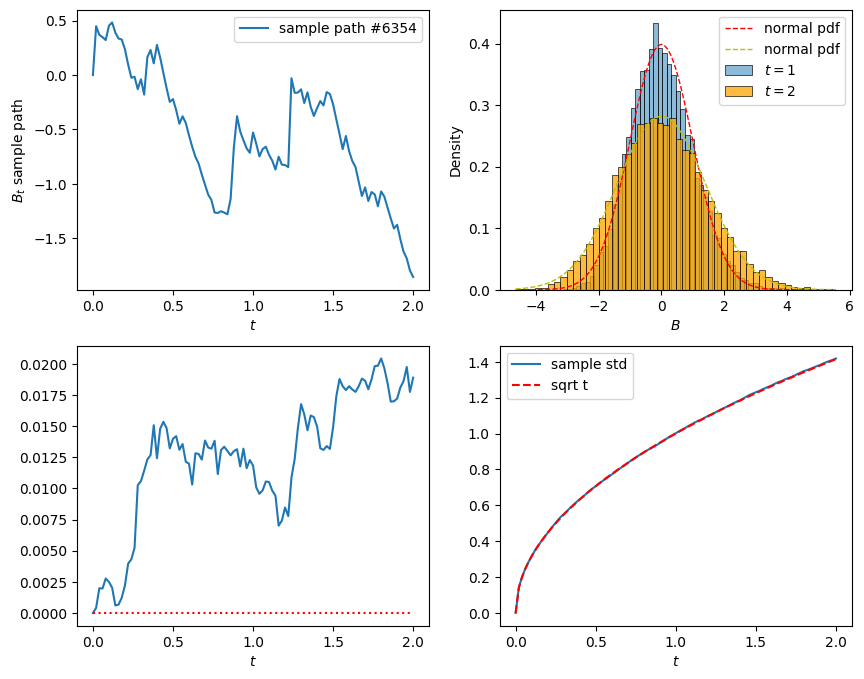

In [3]:
# insert python code for (2b) in this cell
np.random.seed(9527)

# Simulate BM by using the Donsker's invariance principle
# number of samples, number of steps, terminal time
n_sim, n_steps, T = 15000, 100, 2  
dt = T/n_steps

# initialize the Brownians
B = np.zeros([n_sim, n_steps+1])

# simulation step
for i in range(n_steps):
    dB = ss.expon.rvs(size=n_sim) 
    # dB = dB - dB.mean() # now dB has mean 0
    # dB = dB/dB.std()  # now dB has variance 1
    # exp(1) mean 1 var 1
    dB=dB-1
    dB = np.sqrt(dt)*dB
    B[:,i+1] = B[:,i] + dB 

    
#===========
# plot
t = np.arange(0, T+dt, dt)
#t = np.linspace(0, T, n_steps+1)
plt.figure(figsize=(10, 8))

# sample path
path = np.random.choice(n_sim)
plt.subplot(2, 2, 1)
plt.plot(t, B[path, :], label=f'sample path #{path}')
plt.xlabel('$t$')
plt.ylabel('$B_t$ sample path')
plt.legend()

# histograms
plt.subplot(2, 2, 2)
time = 1
sns.histplot(B[:,t==time], bins=50, stat='density', label=f'$t={time}$')
sns.histplot(B[:,-1], bins=50, stat='density', color='orange', label=f'$t={T}$')
x = np.linspace(B[:,-1].min(), B[:,-1].max(), 100)
plt.plot(x, norm.pdf(x), 'r--', lw=1, label='normal pdf')
plt.plot(x, norm.pdf(x, scale=sqrt(2)), 'y--', lw=1, label='normal pdf')
plt.xlabel('$B$')
plt.legend();

# sample mean
plt.subplot(2, 2, 3)
plt.plot(t, B.mean(axis=0))
plt.hlines(y=0, xmin=0, xmax=T, color='red', ls='dotted')
plt.xlabel('$t$')


# sampel standard deviation
plt.subplot(2, 2, 4)
plt.plot(t, B.std(axis=0), label='sample std')
plt.plot(t, np.sqrt(t), 'r--', label='sqrt t')
plt.xlabel('$t$')
plt.legend();

### 3. (10pts)
Alter the `python` code provided in the lecture to simulate the process $X_t$ given by

$$
X_t = 1 + 3t(2-t) + B_t,
$$

for $0 \leq t \leq 2$. Use $200$ time steps and generate $20,000$ sample paths, plot sample mean, sample standard deviation (as functions of $t$), and the histograms at $t = 1$ and $t=2$.  To begin with, set `numpy.random.seed(1732)`. 

### <font color=blue> Solution 3. </font>

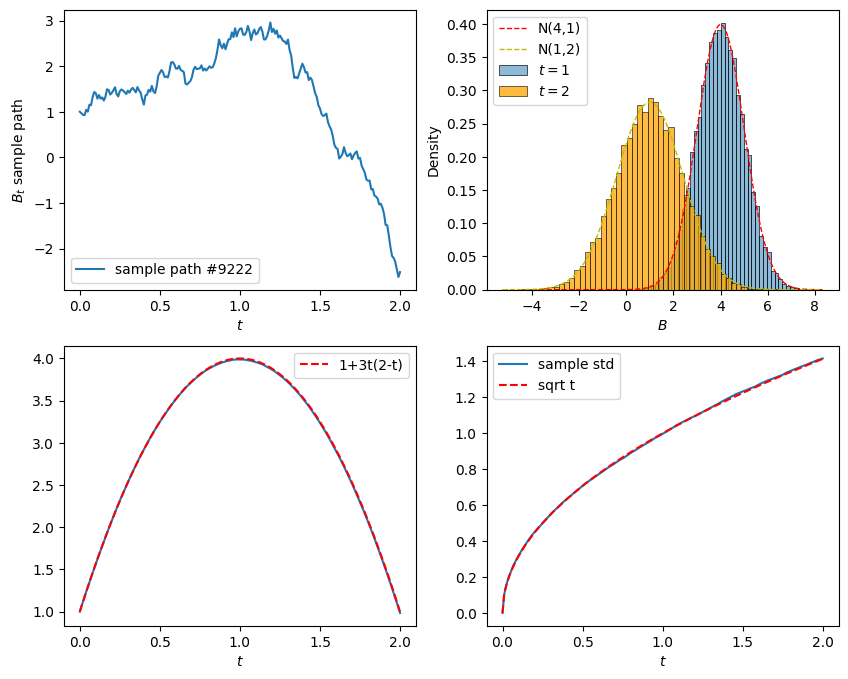

In [4]:
# insert python code for (3) in this cell
np.random.seed(1732)

# Simulate BM by using the Donsker's invariance principle
# number of samples, number of steps, terminal time
n_sim, n_steps, T = 20000, 200, 2  
dt = T/n_steps

# initialize the Brownians
B = np.zeros([n_sim, n_steps+1])

# simulation step
for i in range(n_steps):
    dB = norm.rvs(size=n_sim)
    dB = np.sqrt(dt)*dB
    B[:,i+1] = B[:,i] + dB 

t = np.linspace(0, T, n_steps+1)

# X_t 仍然用变量B存储
B = B + 1 + 3*t*(2-t)
    
#===========
# plot
t = np.arange(0, T+dt, dt)
#t = np.linspace(0, T, n_steps+1)
plt.figure(figsize=(10, 8))

# sample path
path = np.random.choice(n_sim)
plt.subplot(2, 2, 1)
plt.plot(t, B[path, :], label=f'sample path #{path}')
plt.xlabel('$t$')
plt.ylabel('$B_t$ sample path')
plt.legend()

# histograms
plt.subplot(2, 2, 2)
time = 1
sns.histplot(B[:,t==time], bins=50, stat='density', label=f'$t={time}$')
sns.histplot(B[:,-1], bins=50, stat='density', color='orange', label=f'$t={T}$')

#x = np.linspace(B[:,-1].min(), B[:,-1].max(), 100)
#plt.plot(x, norm.pdf(x), 'r--', lw=1, label='normal pdf')
#plt.plot(x, norm.pdf(x, scale=sqrt(time)), 'y--', lw=1, label='normal pdf')
x = np.linspace(B.min(), B.max(), 300)
# X_1 ~ N(4, 1)
plt.plot(x, norm.pdf(x, loc=4),
         'r--', lw=1, label='N(4,1)')
# X_2 ~ N(1, 2)
plt.plot(x, norm.pdf(x, loc=1, scale=sqrt(2)),
         'y--', lw=1, label='N(1,2)')

plt.xlabel('$B$')
plt.legend();

# sample mean
plt.subplot(2, 2, 3)
plt.plot(t, B.mean(axis=0))
# plt.hlines(y=0, xmin=0, xmax=T, color='red', ls='dotted')
plt.plot(t, 1 + 3*t*(2-t), 'r--', label='1+3t(2-t)')
plt.xlabel('$t$')
plt.legend()


# sampel standard deviation
plt.subplot(2, 2, 4)
plt.plot(t, B.std(axis=0), label='sample std')
plt.plot(t, np.sqrt(t), 'r--', label='sqrt t')
plt.xlabel('$t$')
plt.legend();